# Credit Card Approval Prediction System
### Data Preprocessing, EDA, Feature Engineering & Model Training

This notebook walks through the full ML pipeline described in the project instructions:
1. Environment setup
2. Dataset loading & understanding
3. Data visualization & analysis (EDA)
4. Data preprocessing & feature engineering
5. Machine learning model building (4 classifiers)
6. Model evaluation and best-model selection

The trained artifacts produced here (`best_model.pkl`, `scaler.pkl`, `label_encoders.pkl`)
are consumed directly by the Flask web application (`app.py`).

## 1. Environment Setup & Package Installation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from xgboost import XGBClassifier
import joblib

sns.set_style("whitegrid")
%matplotlib inline

## 2. Dataset Collection & Understanding

We use two source files mirroring the public Credit Card Approval dataset schema:
- `application_record.csv` — applicant demographic & financial attributes
- `credit_record.csv` — monthly payment status history per applicant

> If you have your own dataset, drop it into the `data/` folder with the same
> column names and re-run this notebook end to end.

In [2]:
app_df = pd.read_csv("../data/application_record.csv")
credit_df = pd.read_csv("../data/credit_record.csv")

print("Application records:", app_df.shape)
print("Credit records:", credit_df.shape)
app_df.head()

Application records: (6000, 17)
Credit records: (81336, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,1000001,M,N,N,1,187000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-23803,-4035,1,0,0,High skill tech staff,3
1,1000002,F,Y,Y,0,314800.0,Working,Incomplete higher,Separated,Rented apartment,-25136,-1054,0,1,0,Laborers,1
2,1000003,F,N,Y,0,284900.0,Working,Higher education,Married,House / apartment,-24604,-2615,0,1,0,Accountants,2
3,1000004,F,N,N,1,200900.0,State servant,Secondary / secondary special,Married,House / apartment,-11350,-7394,0,1,0,Medicine staff,3
4,1000005,M,Y,Y,2,140800.0,State servant,Secondary / secondary special,Married,With parents,-8488,-6026,0,0,0,Drivers,4


In [3]:
app_df.info()
print()
app_df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   6000 non-null   int64  
 1   CODE_GENDER          6000 non-null   str    
 2   FLAG_OWN_CAR         6000 non-null   str    
 3   FLAG_OWN_REALTY      6000 non-null   str    
 4   CNT_CHILDREN         6000 non-null   int64  
 5   AMT_INCOME_TOTAL     6000 non-null   float64
 6   NAME_INCOME_TYPE     6000 non-null   str    
 7   NAME_EDUCATION_TYPE  6000 non-null   str    
 8   NAME_FAMILY_STATUS   6000 non-null   str    
 9   NAME_HOUSING_TYPE    6000 non-null   str    
 10  DAYS_BIRTH           6000 non-null   int64  
 11  DAYS_EMPLOYED        6000 non-null   int64  
 12  FLAG_WORK_PHONE      6000 non-null   int64  
 13  FLAG_PHONE           6000 non-null   int64  
 14  FLAG_EMAIL           6000 non-null   int64  
 15  OCCUPATION_TYPE      6000 non-null   str    
 16 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,6000.0,NaN,NaN,NaN,1003000.5,1732.195139,1000001.0,1001500.75,1003000.5,1004500.25,1006000.0
CODE_GENDER,6000,2,F,3267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,6000,2,N,3584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,6000,2,Y,3900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,6000.0,NaN,NaN,NaN,0.8185,1.059125,0.0,0.0,0.0,1.0,4.0
AMT_INCOME_TOTAL,6000.0,NaN,NaN,NaN,183172.016667,76408.774488,30000.0,127500.0,179000.0,230125.0,488700.0
NAME_INCOME_TYPE,6000,5,Working,3176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,6000,5,Secondary / secondary special,2712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,6000,5,Married,3508,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,6000,6,House / apartment,4194,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
credit_df["STATUS"].value_counts()

STATUS
C    29694
X    28421
0    12518
1     7383
2     1679
3      814
4      510
5      317
Name: count, dtype: int64

## 3. Data Visualization & Analysis (EDA)

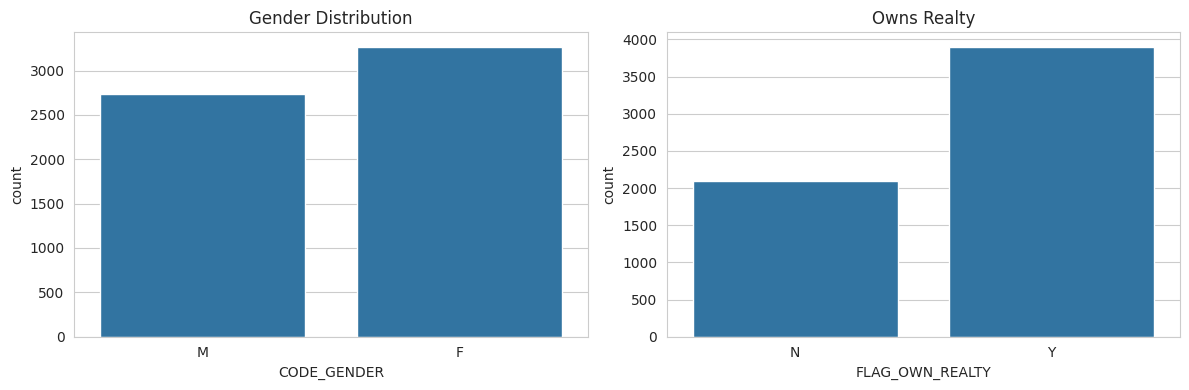

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="CODE_GENDER", data=app_df, ax=axes[0])
axes[0].set_title("Gender Distribution")
sns.countplot(x="FLAG_OWN_REALTY", data=app_df, ax=axes[1])
axes[1].set_title("Owns Realty")
plt.tight_layout()
plt.show()

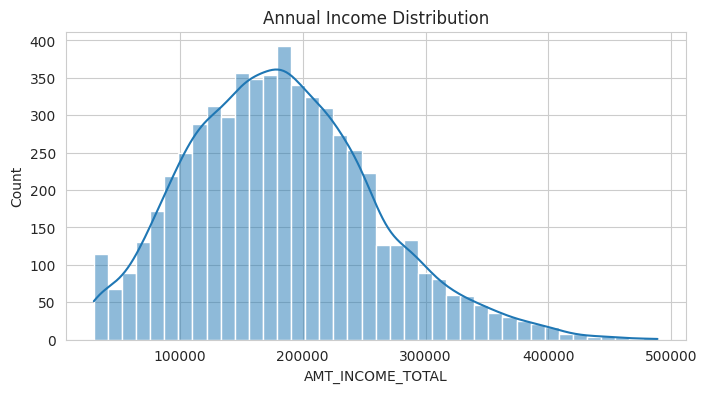

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(app_df["AMT_INCOME_TOTAL"], bins=40, kde=True)
plt.title("Annual Income Distribution")
plt.show()

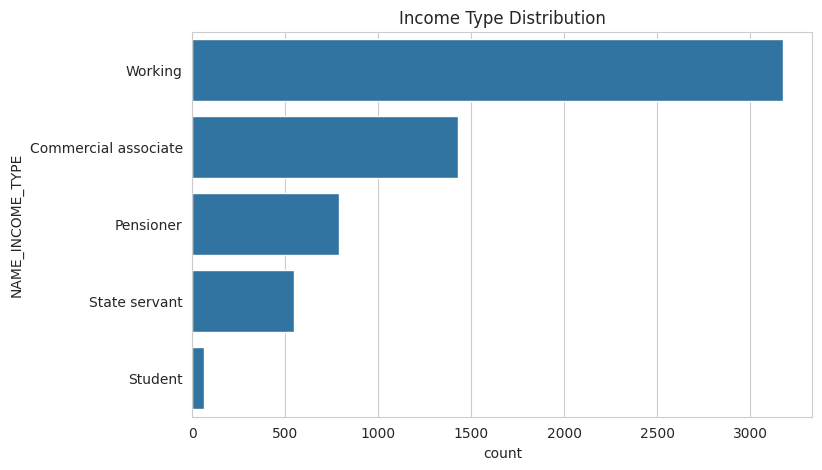

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(y="NAME_INCOME_TYPE", data=app_df,
              order=app_df["NAME_INCOME_TYPE"].value_counts().index)
plt.title("Income Type Distribution")
plt.show()

## 4. Data Preprocessing & Feature Engineering

- Convert multi-class `STATUS` payment codes into a binary target
  (1 = ever 60+ days past due -> high risk / rejected, 0 = approved)
- Handle missing values, drop duplicates
- Engineer `AGE_YEARS`, `EMPLOYMENT_YEARS`, `IS_CURRENTLY_EMPLOYED`
- Label-encode categorical variables

In [8]:
credit_df["IS_BAD_MONTH"] = credit_df["STATUS"].isin(["2","3","4","5"]).astype(int)
bad_counts = credit_df.groupby("ID")["IS_BAD_MONTH"].sum().reset_index()
bad_counts["TARGET"] = (bad_counts["IS_BAD_MONTH"] >= 1).astype(int)
risk_per_id = bad_counts[["ID","TARGET"]]

df = app_df.merge(risk_per_id, on="ID", how="inner")
df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Unknown")
df = df.dropna().drop_duplicates()

df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)
df["EMPLOYMENT_YEARS"] = df["DAYS_EMPLOYED"].apply(lambda x: 0 if x > 0 else round(-x/365, 1))
df["IS_CURRENTLY_EMPLOYED"] = (df["DAYS_EMPLOYED"] < 0).astype(int)

print("Processed shape:", df.shape)
print(df["TARGET"].value_counts(normalize=True))
df.head()

Processed shape: (6000, 21)
TARGET
0    0.817833
1    0.182167
Name: proportion, dtype: float64


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE_YEARS,EMPLOYMENT_YEARS,IS_CURRENTLY_EMPLOYED
0,1000001,M,N,N,1,187000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,...,-4035,1,0,0,High skill tech staff,3,1,65,11.1,1
1,1000002,F,Y,Y,0,314800.0,Working,Incomplete higher,Separated,Rented apartment,...,-1054,0,1,0,Laborers,1,0,68,2.9,1
2,1000003,F,N,Y,0,284900.0,Working,Higher education,Married,House / apartment,...,-2615,0,1,0,Accountants,2,0,67,7.2,1
3,1000004,F,N,N,1,200900.0,State servant,Secondary / secondary special,Married,House / apartment,...,-7394,0,1,0,Medicine staff,3,0,31,20.3,1
4,1000005,M,Y,Y,2,140800.0,State servant,Secondary / secondary special,Married,With parents,...,-6026,0,0,0,Drivers,4,0,23,16.5,1


In [9]:
categorical_cols = ["CODE_GENDER","FLAG_OWN_CAR","FLAG_OWN_REALTY","NAME_INCOME_TYPE",
                    "NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS","NAME_HOUSING_TYPE","OCCUPATION_TYPE"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + "_ENC"] = le.fit_transform(df[col])
    encoders[col] = le

feature_cols = ["CODE_GENDER_ENC","FLAG_OWN_CAR_ENC","FLAG_OWN_REALTY_ENC","CNT_CHILDREN",
                 "AMT_INCOME_TOTAL","NAME_INCOME_TYPE_ENC","NAME_EDUCATION_TYPE_ENC",
                 "NAME_FAMILY_STATUS_ENC","NAME_HOUSING_TYPE_ENC","AGE_YEARS",
                 "EMPLOYMENT_YEARS","IS_CURRENTLY_EMPLOYED","FLAG_WORK_PHONE","FLAG_PHONE",
                 "FLAG_EMAIL","OCCUPATION_TYPE_ENC","CNT_FAM_MEMBERS"]

X = df[feature_cols]
y = df["TARGET"]
X.head()

,CODE_GENDER_ENC,FLAG_OWN_CAR_ENC,FLAG_OWN_REALTY_ENC,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE_ENC,NAME_EDUCATION_TYPE_ENC,NAME_FAMILY_STATUS_ENC,NAME_HOUSING_TYPE_ENC,AGE_YEARS,EMPLOYMENT_YEARS,IS_CURRENTLY_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE_ENC,CNT_FAM_MEMBERS
0,1,0,0,1,187000.0,0,4,1,1,65,11.1,1,1,0,0,3,3
1,0,1,1,0,314800.0,4,2,2,4,68,2.9,1,0,1,0,4,1
2,0,0,1,0,284900.0,4,1,1,1,67,7.2,1,0,1,0,0,2
3,0,0,0,1,200900.0,2,4,1,1,31,20.3,1,0,1,0,6,3
4,1,1,1,2,140800.0,2,4,1,5,23,16.5,1,0,0,0,2,4


## 5. Machine Learning Model Building

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (4800, 17)  Test: (1200, 17)


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced",
                                              random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric="logloss", random_state=42, n_jobs=-1),
}

results = {}
fitted = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:,1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    results[name] = {"accuracy": acc, "roc_auc": auc}
    fitted[name] = model

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}  ROC-AUC: {auc:.4f}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, target_names=["Approved","Rejected"]))


Logistic Regression
Accuracy: 0.7608  ROC-AUC: 0.8320
[[743 238]
 [ 49 170]]
              precision    recall  f1-score   support

    Approved       0.94      0.76      0.84       981
    Rejected       0.42      0.78      0.54       219

    accuracy                           0.76      1200
   macro avg       0.68      0.77      0.69      1200
weighted avg       0.84      0.76      0.78      1200


Decision Tree
Accuracy: 0.7542  ROC-AUC: 0.7642
[[765 216]
 [ 79 140]]
              precision    recall  f1-score   support

    Approved       0.91      0.78      0.84       981
    Rejected       0.39      0.64      0.49       219

    accuracy                           0.75      1200
   macro avg       0.65      0.71      0.66      1200
weighted avg       0.81      0.75      0.77      1200




Random Forest
Accuracy: 0.8292  ROC-AUC: 0.8102
[[882  99]
 [106 113]]
              precision    recall  f1-score   support

    Approved       0.89      0.90      0.90       981
    Rejected       0.53      0.52      0.52       219

    accuracy                           0.83      1200
   macro avg       0.71      0.71      0.71      1200
weighted avg       0.83      0.83      0.83      1200


XGBoost
Accuracy: 0.7825  ROC-AUC: 0.7908
[[808 173]
 [ 88 131]]
              precision    recall  f1-score   support

    Approved       0.90      0.82      0.86       981
    Rejected       0.43      0.60      0.50       219

    accuracy                           0.78      1200
   macro avg       0.67      0.71      0.68      1200
weighted avg       0.82      0.78      0.80      1200



## 6. Model Comparison & Selection

In [12]:
comparison_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
comparison_df

,accuracy,roc_auc
Logistic Regression,0.760833,0.832009
Random Forest,0.829167,0.810244
XGBoost,0.782500,0.790797
Decision Tree,0.754167,0.764249


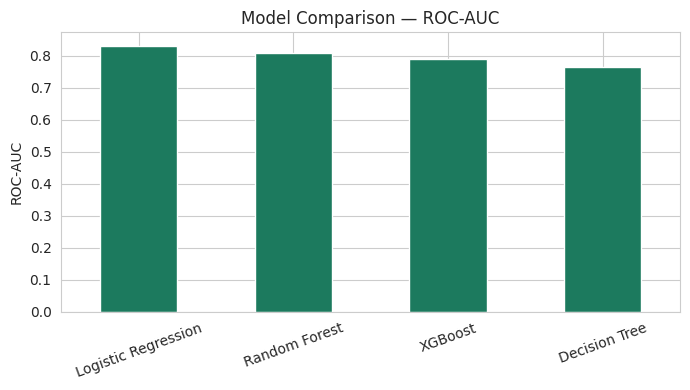

In [13]:
plt.figure(figsize=(7,4))
comparison_df["roc_auc"].plot(kind="bar", color="#1C7A5E")
plt.title("Model Comparison — ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [14]:
best_name = comparison_df.index[0]
best_model = fitted[best_name]
print("Best model:", best_name)

joblib.dump(best_model, "../model/best_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(encoders, "../model/label_encoders.pkl")
joblib.dump(feature_cols, "../model/feature_columns.pkl")
with open("../model/best_model_name.txt","w") as f:
    f.write(best_name)
print("Artifacts saved to ../model/")

Best model: Logistic Regression
Artifacts saved to ../model/


## Next step

The saved artifacts (`best_model.pkl`, `scaler.pkl`, `label_encoders.pkl`,
`feature_columns.pkl`) are loaded directly by `app.py` to power the Flask
web application's real-time prediction interface.